# Hands-on: Anomalib PatchCore

This notebook trains PatchCore on the prepared dataset in `dataset/`. It uses the module-local `Python (V1_D2 Anomaly)` kernel created by `setup_workshop_env.ps1`.

## Context

The previous notebook checked, with whole-image embeddings, whether a pretrained backbone can even tell normal and defective steel apart. This notebook builds the real thing: Anomalib's implementation of PatchCore, using **local patch** embeddings (not whole-image ones), a proper coreset-reduced memory bank, and calibrated image-level metrics.

You will not write PatchCore from scratch. That would take far longer than a workshop session, and `anomalib` is a maintained, tested library used in real industrial deployments. Instead, this notebook is built around Anomalib's own building blocks (`Folder`, `Patchcore`, `Engine`), with a deliberate amount of explanation about what each one is doing under the hood, so that using a library does not mean using a black box. By the end, you will fit and evaluate PatchCore end to end, inspect its heatmaps on real steel images, and compare backbones and hyperparameters quantitatively.


In [16]:
import os
from pathlib import Path

MODULE_ROOT = Path(f"/projappl/project_465002387/DEEP_Inspection_Material_Science/users/{os.environ['USER']}")

DATASET_ROOT =  Path(r'/projappl/project_465002387/DEEP_Inspection_Material_Science/data') / 'dataset_anomaly'
MODEL_CACHE = MODULE_ROOT / '_model_cache'
MODEL_CACHE.mkdir(parents=True, exist_ok=True)

os.environ.setdefault('TORCH_HOME', str(MODEL_CACHE / 'torch'))
os.environ.setdefault('HF_HOME', str(MODEL_CACHE / 'huggingface'))
os.environ.setdefault('HF_HUB_DISABLE_SYMLINKS_WARNING', '1')

print('Module root:', MODULE_ROOT)
print('Dataset root:', DATASET_ROOT)
print('Model cache:', MODEL_CACHE)


Module root: /projappl/project_465002387/DEEP_Inspection_Material_Science/users/saeedima
Dataset root: /projappl/project_465002387/DEEP_Inspection_Material_Science/data/dataset_anomaly
Model cache: /projappl/project_465002387/DEEP_Inspection_Material_Science/users/saeedima/_model_cache


In [17]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
from anomalib.data import Folder
from anomalib.engine import Engine
from anomalib.models import Patchcore


## 1. Confirm the Prepared Dataset

PatchCore memory building uses only normal training images. The defect images are used for testing and discussion.

This first cell is a habit worth keeping in any real project, not just this workshop: **assert your assumptions about the data before spending minutes fitting a model on top of them.** If `train/normal` accidentally pointed at the wrong folder, or `prepare_workshop_dataset.py` had not been (re-)run, the failure would otherwise show up much later as a confusing metric rather than a clear, immediate error here.


In [18]:
metadata = pd.read_csv(DATASET_ROOT / 'metadata.csv')
display(metadata.groupby(['workshop_split', 'label']).size())
display(metadata[metadata['label'] == 'defect']['defect_class'].value_counts())

assert (DATASET_ROOT / 'anomaly' / 'train' / 'normal').exists()
assert (DATASET_ROOT / 'anomaly' / 'test' / 'normal').exists()
assert (DATASET_ROOT / 'anomaly' / 'test' / 'defect').exists()


workshop_split  label 
test/defect     defect    400
test/normal     normal    200
train/normal    normal    600
dtype: int64

defect_class
defect_3                      119
defect_1                       53
defect_4                       46
defect_2                       45
defect_3+defect_4              44
defect_1+defect_3              41
defect_1+defect_2              35
defect_2+defect_3              14
defect_1+defect_2+defect_3      2
defect_2+defect_4               1
Name: count, dtype: int64

The three folders being asserted above map directly onto Anomalib's `Folder` datamodule in Section 3: `normal_dir` (`train/normal`), `normal_test_dir` (`test/normal`), and `abnormal_dir` (`test/defect`). Anomalib does not need a `train/defect` folder at all. There is deliberately no such thing in this dataset, because PatchCore is never allowed to look at a single defect image while building its memory bank.


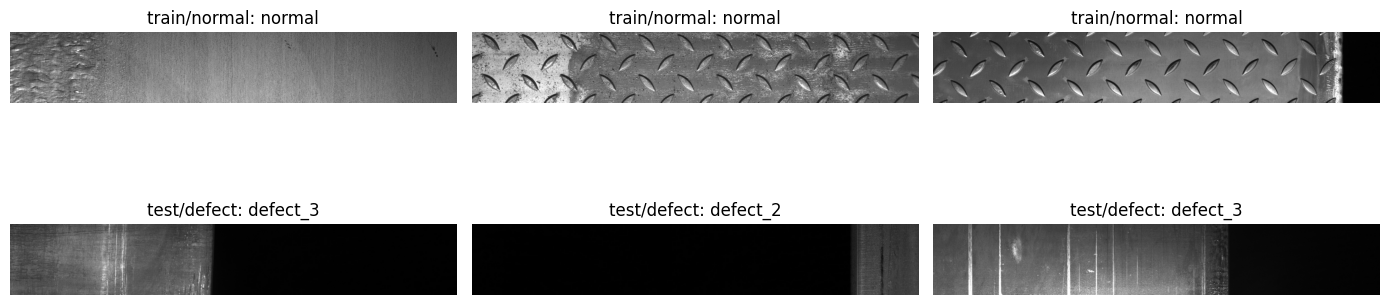

In [19]:
samples = pd.concat([
    metadata[metadata['workshop_split'] == 'train/normal'].sample(3, random_state=10),
    metadata[metadata['workshop_split'] == 'test/defect'].sample(3, random_state=11),
])
fig, axes = plt.subplots(2, 3, figsize=(14, 5))
for ax, (_, row) in zip(axes.ravel(), samples.iterrows()):
    ax.imshow(Image.open(DATASET_ROOT / row.relative_path).convert('RGB'))
    ax.set_title(f"{row.workshop_split}: {row.defect_class}")
    ax.axis('off')
plt.tight_layout()


## 2. Choose a PatchCore Preset

Start with `fast_resnet18` to verify the workflow. `PATCHCORE_PRESETS` has five options spanning a fast CNN, a strong CNN baseline, a modern ConvNeXt CNN, a lightweight EfficientNet, and a DINOv2 transformer. Each preset also sets `num_neighbors`: the number of nearest memory-bank neighbors averaged into each patch's anomaly score (a real `Patchcore` constructor argument, default `9`, not previously exposed here). More intuitively, `num_neighbors` is the number of "votes" each patch gets on whether it is anomalous, based on the distance from its nearest neighbors in the memory bank. The default of 9 is a good balance between robustness and sensitivity, but you can experiment with it later. The final "vote" is the average of the distances to the nearest neighbors, which is then normalized into a 0-1 anomaly score.

### What `layers` actually selects

The theory notebook's explained that early CNN layers capture edges and texture, while later layers capture larger, more semantic shapes. `layers` is where that distinction becomes a concrete choice: it tells Anomalib which intermediate feature maps to pull out of the backbone and use as patch descriptors (for example `'layer2'` and `'layer3'` for the ResNet family). PatchCore deliberately avoids the *first* layer (too raw, mostly edges and color, not distinctive) and the *last* layer (too semantic and coarse-grained -- by the time a CNN has decided "this looks like a generic object", it has thrown away the fine texture detail steel defects actually live in). The middle layers are typically the sweet spot for exactly this kind of local-texture anomaly detection, which is why every preset here picks two adjacent mid-network stages.


A word of caution on `coreset_sampling_ratio`: coreset selection is a sequential greedy algorithm (Section 4.2 of the theory notebook shows exactly how it works), so its cost scales roughly with `coreset_size x feature_dimensions` per training run, not just with the ratio. That is why the ratios below vary so much across presets: `wide_resnet50_2` has about 4x more feature channels per patch than `resnet18`, so its ratio is set roughly 4x lower to land in a similar runtime ballpark, and `efficientnet_b0`'s much smaller feature dimension means it can afford a higher ratio for the same cost. If you raise any of these when running the models, expect a real (sometimes large) runtime hit, not just "a bit slower", and expect that effect to be much stronger for the CNNs with more channels.


In [20]:
PATCHCORE_PRESETS = {
    'fast_resnet18': {
        'backbone': 'resnet18',
        'layers': ['layer2', 'layer3'],
        'coreset_sampling_ratio': 0.01,
        'num_neighbors': 5,
        'train_batch_size': 32,
        'eval_batch_size': 32,
        'note': 'fastest smoke test, weakest features',
    },
    'baseline_wide_resnet50_2': {
        'backbone': 'wide_resnet50_2',
        'layers': ['layer2', 'layer3'],
        'coreset_sampling_ratio': 0.002,
        'num_neighbors': 9,
        'train_batch_size': 16,
        'eval_batch_size': 16,
        'note': 'classic PatchCore paper baseline',
    },
    'strong_convnext_tiny': {
        'backbone': 'convnext_tiny',
        'layers': ['stages.1', 'stages.2'],
        'coreset_sampling_ratio': 0.005,
        'num_neighbors': 9,
        'train_batch_size': 16,
        'eval_batch_size': 16,
        'note': 'modern ConvNeXt CNN',
    },
    'efficient_effnet_b0': {
        'backbone': 'efficientnet_b0',
        'layers': ['blocks.2', 'blocks.4'],
        'coreset_sampling_ratio': 0.02,
        'num_neighbors': 9,
        'train_batch_size': 32,
        'eval_batch_size': 32,
        'note': 'lightweight/mobile-oriented CNN, fewer params',
    },
    'transformer_dinov2_vit_s': {
        'backbone': 'vit_small_patch14_dinov2.lvd142m',
        'layers': ['blocks.9', 'blocks.10', 'blocks.11'],
        'coreset_sampling_ratio': 0.0025,
        'num_neighbors': 5,
        'train_batch_size': 8,
        'eval_batch_size': 8,
        'image_size': (518, 518),  # this DINOv2 checkpoint was pretrained at 518x518 and errors on any other input size
        'note': 'transformer, self-supervised DINOv2 features',
    },
}

SELECTED_PRESET = 'fast_resnet18'
config = PATCHCORE_PRESETS[SELECTED_PRESET]
config


{'backbone': 'resnet18',
 'layers': ['layer2', 'layer3'],
 'coreset_sampling_ratio': 0.01,
 'num_neighbors': 5,
 'train_batch_size': 32,
 'eval_batch_size': 32,
 'note': 'fastest smoke test, weakest features'}

## 3. Build Anomalib Objects

The `Folder` datamodule points to the prepared local dataset. The `Patchcore` model receives the selected backbone and feature layers.

### What each object is actually responsible for

It helps to know what these three lines are actually standing in for, since none of them do very much by themselves. They configure work that happens later:

- **`Folder`** is a PyTorch Lightning `DataModule`: it scans the three directories you asserted in Section 1, builds a `Dataset`/`DataLoader` pair for training and one for testing, and applies a default resize + normalization transform matching the chosen backbone. You are not writing any file-scanning or batching code. `Folder` is doing exactly what `SteelImageDataset` did by hand in the previous notebook, generalized to Anomalib's whole model zoo.
- **`Patchcore`** is the model *definition*: which backbone, which layers, how aggressively to shrink the memory bank, how many neighbors to average. Building it does essentially no work yet, it just downloads/loads the pretrained backbone weights and allocates an empty memory bank.
- **`Engine`** is Anomalib's thin wrapper around a PyTorch Lightning `Trainer`. It is what actually *runs* things later (`engine.fit(...)`, `engine.test(...)`), picking CPU or GPU, looping over batches, and calling the right methods on the model at the right time. Anomalib uses Lightning under the hood for every one of its ~20 different anomaly detection models, so switching from PatchCore to a different method later would reuse this exact same `Engine` pattern.

One detail is backbone-specific: Anomalib resizes every image to `256x256` by default, which is fine for the CNN backbones but wrong for `vit_small_patch14_dinov2.lvd142m`. That checkpoint was pretrained at a fixed `518x518` resolution and raises an error on any other input size. The `image_size` key in that preset overrides the default resize via `Patchcore.configure_pre_processor(...)`; the other presets leave it unset and get Anomalib's default.


In [21]:
datamodule = Folder(
    name='severstal_patchcore',
    root=DATASET_ROOT / 'anomaly',
    normal_dir='train/normal',
    abnormal_dir='test/defect',
    normal_test_dir='test/normal',
    train_batch_size=config['train_batch_size'],
    eval_batch_size=config['eval_batch_size'],
    num_workers=0,
)

pre_processor = Patchcore.configure_pre_processor(image_size=config['image_size']) if config.get('image_size') else True
model = Patchcore(
    backbone=config['backbone'],
    layers=config['layers'],
    pre_trained=True,
    coreset_sampling_ratio=config['coreset_sampling_ratio'],
    num_neighbors=config['num_neighbors'],
    pre_processor=pre_processor,
)

accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'
engine = Engine(
    accelerator=accelerator,
    devices=1,
    max_epochs=1,
    logger=False,
    enable_progress_bar=False,  # avoids a rich/Lightning progress-bar crash under headless notebook execution
    default_root_dir=MODULE_ROOT / 'results',
)

print('accelerator:', accelerator)
print(model)


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

accelerator: gpu
Patchcore(
  (pre_processor): PreProcessor(
    (transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=True)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
    (export_transform): Compose(
          Resize(size=[256, 256], interpolation=InterpolationMode.BILINEAR, antialias=False)
          Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
    )
  )
  (post_processor): PostProcessor(
    (_image_threshold_metric): F1AdaptiveThreshold()
    (_pixel_threshold_metric): F1AdaptiveThreshold()
    (_image_min_max_metric): MinMax()
    (_pixel_min_max_metric): MinMax()
  )
  (evaluator): Evaluator(
    (val_metrics): ModuleList()
    (test_metrics): ModuleList(
      (0): AUROC()
      (1): F1Score()
      (2): AUROC()
      (3): F1Score()
    )
  )
  (model): PatchcoreModel(
    (feature_extractor): TimmFeatureExtractor(
      (feature_extractor

## 4. Fit and Test

`fit` extracts normal features and builds the memory bank. There is no classifier fine-tuning loop like in supervised training -- this is also why `Engine` above was created with `max_epochs=1`: PatchCore does not do gradient-based training over multiple epochs the way a CNN classifier would. One pass over the normal training images is enough to extract features and populate the memory bank.

### What happens during `engine.fit(...)`

Concretely, in one pass over every `train/normal` image:

1. Each image is resized/normalized and pushed through the frozen backbone, stopping at the `layers` selected in the preset, exactly the "image → feature map" step from the theory notebook's Section 2, done for every training image.
2. Each feature map is reshaped into a table of local patch vectors (the theory notebook's Section 2.1 `permute` + `reshape` trick), and every patch from every training image is pooled into one large candidate pool.
3. Greedy coreset selection (theory notebook Section 4.2) picks a representative subset of that pool, sized by `coreset_sampling_ratio`.
4. That subset becomes the memory bank, the only thing PatchCore actually "remembers" from the entire training set.

No weights are updated anywhere in this process. The backbone stays exactly as pretrained; only the memory bank (a plain tensor of patch vectors, not a neural network layer) is being populated.

### What happens during `engine.test(...)`

For every image in `test/normal` and `test/defect`: extract its patches the same way, find each patch's nearest neighbor in the memory bank (theory notebook Section 3.1), aggregate patch distances into one image-level score, and compare that score against each image's true label (normal or defect) to compute AUROC and F1. This is also the first point where the ground-truth labels are used at all -- they play no role in `fit`, only in scoring how well the resulting anomaly scores rank defects above normals.


In [22]:
engine.fit(model=model, datamodule=datamodule)
test_results = engine.test(model=model, datamodule=datamodule)
test_results


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │  2.8 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.131                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is inten

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.5018500089645386     │
│       image_F1Score       │    0.7959595918655396     │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 0.5018500089645386, 'image_F1Score': 0.7959595918655396}]

`test_results` is Anomalib's own summary -- the same `image_AUROC`/`image_F1Score` numbers the theory notebook explained conceptually, now computed on your chosen preset and real steel images. Whatever their exact values, treat one number in isolation with caution: Section 7's mini-competition is where these numbers become genuinely informative, by comparing them across presets rather than reading one in a vacuum.


## 5. Predict and Inspect Heatmaps

The score table is useful, but heatmaps are essential for inspection. A high score should ideally correspond to a plausible suspicious region.


In [23]:
predictions = engine.predict(model=model, datamodule=datamodule)
print(type(predictions), len(predictions) if predictions is not None else None)
first = predictions[0] if predictions else None
if first is not None:
    print('first prediction type:', type(first))
    if hasattr(first, 'keys'):
        print('keys:', first.keys())
    else:
        print('attributes:', [name for name in dir(first) if not name.startswith('_')][:50])


ckpt_path is not provided. Model weights will not be loaded.
The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


<class 'list'> 10
first prediction type: <class 'anomalib.data.dataclasses.torch.image.ImageBatch'>
keys: ['image', 'gt_label', 'gt_mask', 'mask_path', 'anomaly_map', 'pred_score', 'pred_mask', 'pred_label', 'explanation', 'image_path']


Anomalib's prediction object schema has changed across versions,sometimes a dict, sometimes a dataclass-like object, with key names like `anomaly_map` vs `pred_mask` moving between releases. Rather than hardcoding one shape and hoping it matches whatever Anomalib version is installed, the helpers below try several plausible names/attributes in order. This defensive style exists only because of that version churn; it is not a general pattern to copy into your own code.

One more detail: `predictions` has one entry per **batch**, not per image (batch size = `eval_batch_size` from the selected preset). `show_prediction` below picks a single sample out of that batch before plotting it.


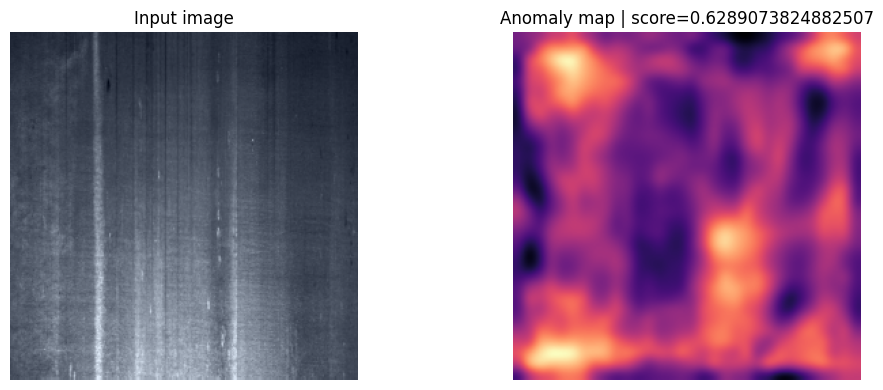

In [24]:
def get_value(pred, *names):
    for name in names:
        if isinstance(pred, dict) and name in pred:
            return pred[name]
        if hasattr(pred, name):
            return getattr(pred, name)
    return None

def as_numpy(value):
    if value is None:
        return None
    if torch.is_tensor(value):
        value = value.detach().cpu()
        if value.ndim == 3 and value.shape[0] in (1, 3):
            value = value.permute(1, 2, 0)
        return value.numpy()
    return np.asarray(value)

def show_prediction(pred, sample_idx=0):
    # engine.predict() returns one entry per *batch*, not per image, so pred['image']
    # etc. still have a leading batch dimension -- index a single sample out of it first.
    image = get_value(pred, 'image')
    anomaly_map = get_value(pred, 'anomaly_map', 'pred_mask')
    score = get_value(pred, 'pred_score', 'score')

    image = as_numpy(image[sample_idx]) if image is not None else None
    anomaly_map = as_numpy(anomaly_map[sample_idx]) if anomaly_map is not None else None
    score = score[sample_idx] if score is not None else None

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    if image is not None:
        image = np.squeeze(image)
        if image.ndim == 3:
            image = (image - image.min()) / max(image.max() - image.min(), 1e-6)
        axes[0].imshow(image)
    axes[0].set_title('Input image')
    axes[0].axis('off')

    if anomaly_map is not None:
        axes[1].imshow(np.squeeze(anomaly_map), cmap='magma')
    axes[1].set_title(f'Anomaly map | score={score}')
    axes[1].axis('off')
    plt.tight_layout()

if predictions:
    show_prediction(predictions[0])


### 5.1 A closer look: several examples and the real score distribution

One example is a start, but it is easy to accidentally pick an unusually easy or unusually hard case. The cells below flatten every batch in `predictions` into plain arrays (one entry per image, not per batch), so we can look at a proper handful of normal and defect examples side by side, and see the actual distribution of anomaly scores this run produced.


In [25]:
def flatten_predictions(predictions):
    images, anomaly_maps, scores, gt_labels = [], [], [], []
    for batch in predictions:
        batch_images = get_value(batch, 'image')
        batch_maps = get_value(batch, 'anomaly_map', 'pred_mask')
        batch_scores = get_value(batch, 'pred_score', 'score')
        batch_gt = get_value(batch, 'gt_label', 'label')
        if batch_images is not None:
            images.extend([as_numpy(img) for img in batch_images])
        if batch_maps is not None:
            anomaly_maps.extend([as_numpy(m) for m in batch_maps])
        if batch_scores is not None:
            scores.extend(as_numpy(batch_scores).tolist())
        if batch_gt is not None:
            gt_labels.extend(as_numpy(batch_gt).tolist())
    return images, anomaly_maps, np.array(scores), np.array(gt_labels)

all_images, all_maps, all_scores, all_gt_labels = flatten_predictions(predictions)
print(f'Flattened {len(all_images)} individual predictions from {len(predictions)} batches.')


Flattened 300 individual predictions from 10 batches.


`all_gt_labels` follows Anomalib's convention: `0` = normal, `1` = defect. These came along for free inside each prediction batch, we did not need to separately look up which folder each test image came from.


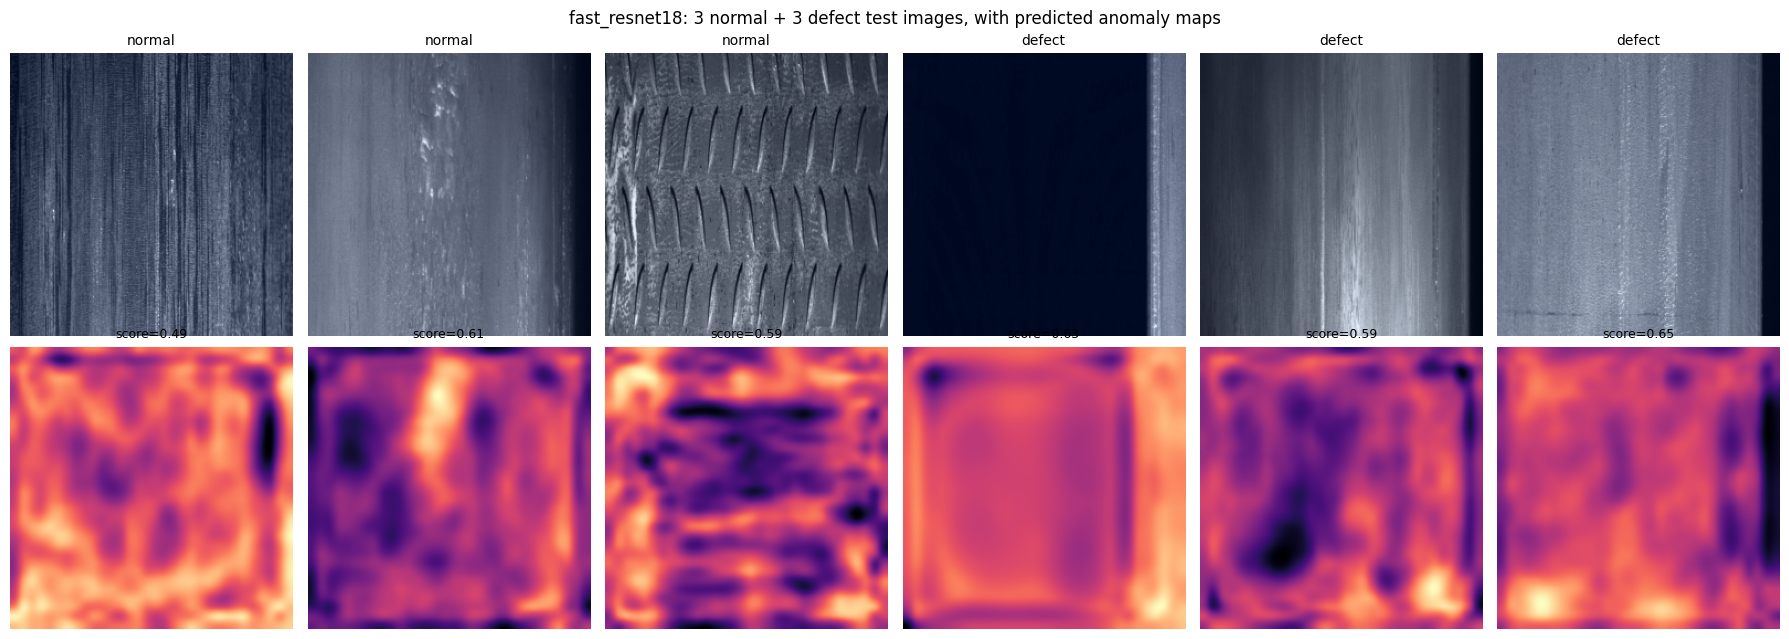

In [26]:
rng = np.random.default_rng(0)
normal_positions = np.where(all_gt_labels == 0)[0]
defect_positions = np.where(all_gt_labels == 1)[0]
grid_positions = list(rng.choice(normal_positions, size=min(3, len(normal_positions)), replace=False)) + \
                 list(rng.choice(defect_positions, size=min(3, len(defect_positions)), replace=False))

fig, axes = plt.subplots(2, len(grid_positions), figsize=(3 * len(grid_positions), 6.5))
for col, pos in enumerate(grid_positions):
    image = np.squeeze(all_images[pos])
    if image.ndim == 3:
        image = (image - image.min()) / max(image.max() - image.min(), 1e-6)
    axes[0, col].imshow(image)
    axes[0, col].set_title('normal' if all_gt_labels[pos] == 0 else 'defect', fontsize=10)
    axes[0, col].axis('off')
    axes[1, col].imshow(np.squeeze(all_maps[pos]), cmap='magma')
    axes[1, col].set_title(f'score={all_scores[pos]:.2f}', fontsize=9)
    axes[1, col].axis('off')
fig.suptitle(f'{SELECTED_PRESET}: 3 normal + 3 defect test images, with predicted anomaly maps')
plt.tight_layout()
plt.show()


Look for two things across these six examples: do the brightest regions of the defect heatmaps actually land on the visible flaw (a convincing detection), or somewhere else entirely like a border or lighting artifact (a right-answer-wrong-reason case, per the theory notebook's Section 7 failure modes)? And do any of the *normal* heatmaps light up anyway, which could bea potential false alarm worth understanding before trusting this preset's F1 number?


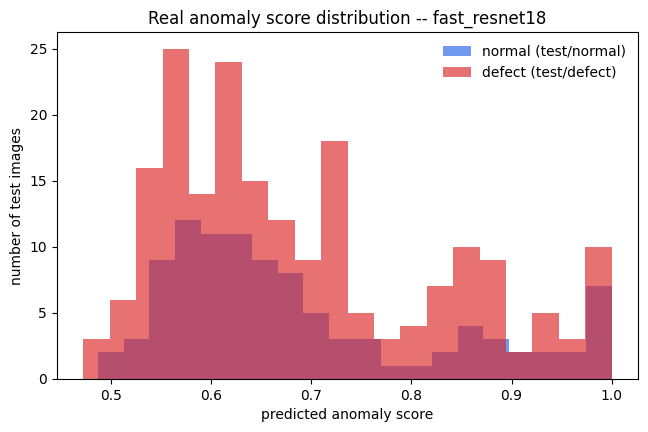

In [27]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.hist(all_scores[all_gt_labels == 0], bins=20, alpha=0.65, label='normal (test/normal)', color='#2563eb')
ax.hist(all_scores[all_gt_labels == 1], bins=20, alpha=0.65, label='defect (test/defect)', color='#dc2626')
ax.set_xlabel('predicted anomaly score')
ax.set_ylabel('number of test images')
ax.set_title(f'Real anomaly score distribution -- {SELECTED_PRESET}')
ax.legend(frameon=False)
plt.show()


This is the real, measured version of the theory notebook's Figure 13. If the blue (normal) and red (defect) histograms overlap heavily, no threshold choice can cleanly separate them. That overlap *is* what a mediocre AUROC looks like in practice, not an abstract number. If they separate with only a little overlap, there is a real range of thresholds where this preset would do well, and the overlap region is exactly where you would expect the failure cases in the grid above to come from.


## 6. A Reusable Function: Run Any Preset End to End

Steps 3-5 above were done by hand for `fast_resnet18`. The function below packages exactly the same steps: build a datamodule, build a model, build an engine, fit, test, measure timing, so you can call it once per preset without retyping the pipeline. It returns one `PresetResult` per call, bundling the numbers worth comparing across presets: the two real metrics (`image_auroc`, `image_f1`), two proxies for "how much did this preset actually remember and how big is it" (`memory_bank_size`, `backbone_params_m`), and three timings (`fit_time_s`, `test_time_s`, `total_time_s`) so runtime is comparable on equal footing, not just eyeballed from progress bars.

One detail matters: each call builds a **brand-new** `Folder`, `Patchcore`, and `Engine`. Anomalib's `Engine` caches its underlying Lightning trainer the first time you call `fit`/`test` and does not rebuild it on a later call. This means that reusing one `Engine` across multiple presets would silently mix up checkpoints and logs between runs. Building fresh objects per preset avoids that entirely.


In [28]:
import time
import gc
from dataclasses import dataclass

@dataclass
class PresetResult:
    preset_name: str
    backbone: str
    coreset_sampling_ratio: float
    num_neighbors: int
    image_auroc: float
    image_f1: float
    memory_bank_size: int
    backbone_params_m: float
    fit_time_s: float
    test_time_s: float
    total_time_s: float


def get_metric(results_dict, *keys, default=float('nan')):
    # Anomalib's metric key names/prefixes have moved before across versions;
    # try each candidate key name in order rather than hardcoding one.
    for key in keys:
        if key in results_dict:
            return results_dict[key]
    return default


def run_patchcore_preset(preset_name):
    preset_config = PATCHCORE_PRESETS[preset_name]
    accelerator = 'gpu' if torch.cuda.is_available() else 'cpu'

    preset_datamodule = Folder(
        name='severstal_patchcore',
        root=DATASET_ROOT / 'anomaly',
        normal_dir='train/normal',
        abnormal_dir='test/defect',
        normal_test_dir='test/normal',
        train_batch_size=preset_config['train_batch_size'],
        eval_batch_size=preset_config['eval_batch_size'],
        num_workers=0,
    )

    preset_pre_processor = (
        Patchcore.configure_pre_processor(image_size=preset_config['image_size'])
        if preset_config.get('image_size') else True
    )
    preset_model = Patchcore(
        backbone=preset_config['backbone'],
        layers=preset_config['layers'],
        pre_trained=True,
        coreset_sampling_ratio=preset_config['coreset_sampling_ratio'],
        num_neighbors=preset_config['num_neighbors'],
        pre_processor=preset_pre_processor,
    )

    # A fresh Engine per preset -- see markdown above for why.
    preset_engine = Engine(
        accelerator=accelerator,
        devices=1,
        max_epochs=1,
        logger=False,
        enable_progress_bar=False,  # avoids a rich/Lightning progress-bar crash under headless notebook execution
        default_root_dir=MODULE_ROOT / 'results' / preset_name,
    )

    backbone_params_m = sum(p.numel() for p in preset_model.model.feature_extractor.parameters()) / 1e6

    t0 = time.perf_counter()
    preset_engine.fit(model=preset_model, datamodule=preset_datamodule)
    t1 = time.perf_counter()
    preset_test_results = preset_engine.test(model=preset_model, datamodule=preset_datamodule)
    t2 = time.perf_counter()

    stats = preset_test_results[0] if preset_test_results else {}
    result = PresetResult(
        preset_name=preset_name,
        backbone=preset_config['backbone'],
        coreset_sampling_ratio=preset_config['coreset_sampling_ratio'],
        num_neighbors=preset_config['num_neighbors'],
        image_auroc=get_metric(stats, 'image_AUROC'),
        image_f1=get_metric(stats, 'image_F1Score'),
        memory_bank_size=int(preset_model.model.memory_bank.shape[0]),
        backbone_params_m=backbone_params_m,
        fit_time_s=t1 - t0,
        test_time_s=t2 - t1,
        total_time_s=t2 - t0,
    )

    # Release the model/engine before the next preset runs in this same kernel.
    del preset_engine, preset_model, preset_datamodule
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return result


## 7. Mini-Competition: Compare Presets

Pick 2-3 presets to compare, as running all five back to back adds up, and the point is discussion, not brute-force coverage. The image-level AUROC/F1 metrics are the only ones worth trusting here: the `Folder` datamodule was never given a `mask_dir`, so the pixel-level metrics Anomalib also reports are computed against empty ground truth and are not meaningful for this dataset.

If you add a backbone whose weights aren't cached yet in `_model_cache/`, its first run will include a download, run it once ungraded before comparing runtimes, or the download time will confound the comparison.


In [29]:
PRESETS_TO_COMPARE = ['fast_resnet18', 'baseline_wide_resnet50_2', 'transformer_dinov2_vit_s']

preset_results = {}
for name in PRESETS_TO_COMPARE:
    print(f'--- Running preset: {name} ---')
    preset_results[name] = run_patchcore_preset(name)

comparison_df = pd.DataFrame([vars(r) for r in preset_results.values()])
comparison_df = comparison_df.sort_values('image_auroc', ascending=False).reset_index(drop=True)

print('=' * 80)
print('PATCHCORE PRESET COMPARISON')
print('=' * 80)
with pd.option_context('display.float_format', lambda x: f'{x:.4f}'):
    print(comparison_df.to_string(index=False))

best = comparison_df.iloc[0]
print(f"\nBest AUROC: {best['preset_name']} ({best['image_auroc']:.4f}), "
      f"{best['backbone_params_m']:.1f}M backbone params, {best['total_time_s']:.1f}s total")


--- Running preset: fast_resnet18 ---


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:183: `LightningModule.configure_optimizers` returned `None`, this fit will run with no optimizer


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │  2.8 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 2.8 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.8 M                                                                                                
Total estimated model params size (MB): 11.131                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 69                                                                                           
Total FLOPs: 0

/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is inten

...

┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type           ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor   │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor  │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator      │      0 │ train │     0 │
│ 3 │ model          │ PatchcoreModel │ 22.1 M │ train │     0 │
└───┴────────────────┴────────────────┴────────┴───────┴───────┘

Trainable params: 22.1 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 22.1 M                                                                                               
Total estimated model params size (MB): 88.222                                                                     
Modules in train mode: 19                                                                                          
Modules in eval mode: 278                                                                                          
Total FLOPs: 0

/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/projappl/project_465002387/DEEP_Inspection_Material_Science/workshopvenv/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:538: Found 278 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is inte

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.7600499391555786     │
│       image_F1Score       │    0.8169642686843872     │
└───────────────────────────┴───────────────────────────┘

PATCHCORE PRESET COMPARISON
             preset_name                         backbone  coreset_sampling_ratio  num_neighbors  image_auroc  image_f1  memory_bank_size  backbone_params_m  fit_time_s  test_time_s  total_time_s
transformer_dinov2_vit_s vit_small_patch14_dinov2.lvd142m                  0.0025              5       0.7600    0.8170              2053            22.0554     23.6661      14.3609       38.0270
baseline_wide_resnet50_2                  wide_resnet50_2                  0.0020              9       0.6192    0.8016              1228            24.8625     17.2047       7.4152       24.6199
           fast_resnet18                         resnet18                  0.0100              5       0.5918    0.8016              6144             2.7828     19.9451       6.4558       26.4009

Best AUROC: transformer_dinov2_vit_s (0.7600), 22.1M backbone params, 38.0s total


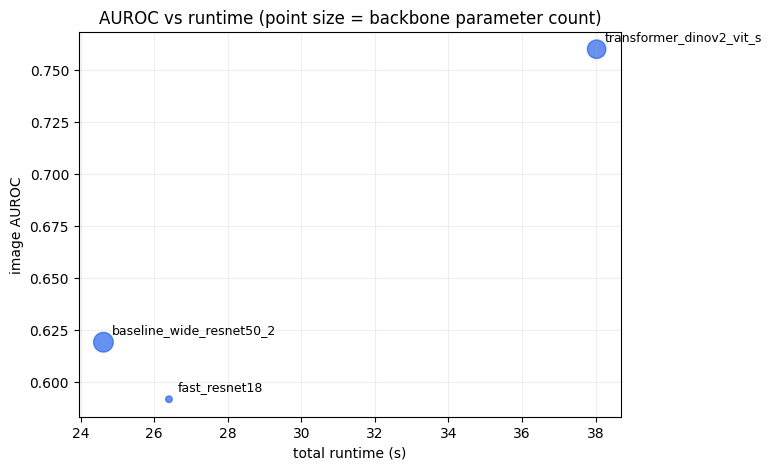

In [30]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(comparison_df['total_time_s'], comparison_df['image_auroc'],
           s=comparison_df['backbone_params_m'] * 8, alpha=0.7, color='#2563eb')
for _, row in comparison_df.iterrows():
    ax.annotate(row['preset_name'], (row['total_time_s'], row['image_auroc']),
                textcoords='offset points', xytext=(6, 6), fontsize=9)
ax.set_xlabel('total runtime (s)')
ax.set_ylabel('image AUROC')
ax.set_title('AUROC vs runtime (point size = backbone parameter count)')
ax.grid(alpha=0.2)
plt.show()


Discuss as a group:

- Which preset won on AUROC? Was it also the fastest? The scatter plot above puts both dimensions on one chart specifically so "best" cannot be answered by AUROC alone. A preset in the top-left (high AUROC, low runtime) is a genuinely different recommendation than one in the top-right (high AUROC, slow).
- Did increasing `coreset_sampling_ratio` or `num_neighbors` visibly help, or mostly just cost runtime?
- Pick one preset's heatmap (rerun Section 5.1 with a different `SELECTED_PRESET` to look closer) and find one convincing detection and one failure case.
- Does the backbone ranking here agree with the silhouette-score ranking from the feature-extraction notebook? If not, remember the two notebooks are not measuring the same thing: whole-image embeddings there, local patch embeddings here.
